# Приклад виконання в Python

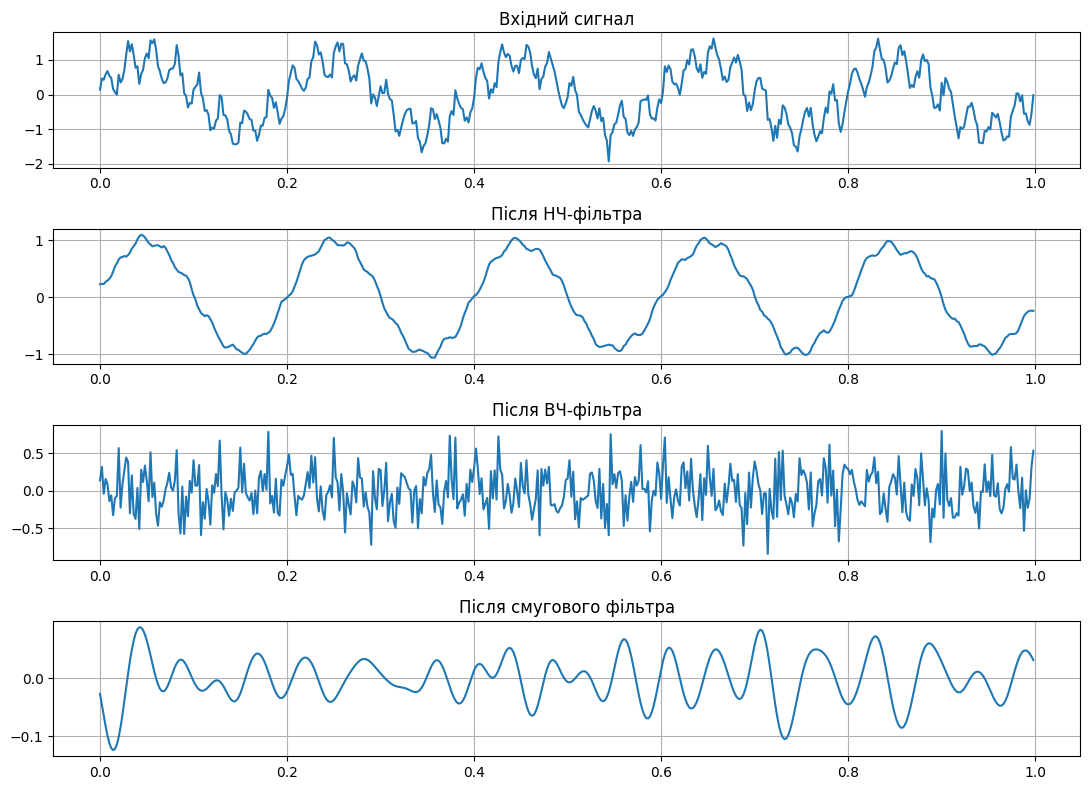

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 1. Параметри сигналу
fs = 500
t = np.arange(0, 1, 1 / fs)

# 2. Тестовий сигнал: повільна + швидка складова + шум
x = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 40 * t)
x = x + 0.15 * np.random.randn(len(t))

# 3. Низькочастотний фільтр FIR (ковзне середнє)
M = 15
h_lp = np.ones(M) / M
y_lp = np.convolve(x, h_lp, mode='same')

# 4. Простий високочастотний фільтр
h_hp = np.array([1, -1])
y_hp = np.convolve(x, h_hp, mode='same')

# 5. Смуговий фільтр Butterworth
b, a = butter(N=4, Wn=[8, 25], btype='bandpass', fs=fs)
y_bp = filtfilt(b, a, x)

# 6. Графіки
plt.figure(figsize=(11, 8))

plt.subplot(4, 1, 1)
plt.plot(t, x)
plt.title("Вхідний сигнал")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, y_lp)
plt.title("Після НЧ-фільтра")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t, y_hp)
plt.title("Після ВЧ-фільтра")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t, y_bp)
plt.title("Після смугового фільтра")
plt.grid(True)

plt.tight_layout()
plt.show()


# Реалізація завдань

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt

# --- ФУНКЦІЇ ОБРОБКИ ---

def calculate_metrics(sig):
    """Обчислення характеристик сигналу"""
    return {
        "Mean": np.mean(sig),
        "Energy": np.sum(sig**2),
        "RMS": np.sqrt(np.mean(sig**2))
    }

def generate_signal(fs=500, duration=1.0, freqs=[5, 40, 100], amps=[1.0, 0.5, 0.3], noise_std=0):
    """Генерація сигналу з довільною кількістю гармонік та шумом"""
    t = np.arange(0, duration, 1/fs)
    x = np.zeros_like(t)
    for f, a in zip(freqs, amps):
        x += a * np.sin(2 * np.pi * f * t)
    if noise_std > 0:
        x += np.random.normal(0, noise_std, len(t))
    return t, x

def apply_low_pass_fir(sig, M, mode = 'same'):
    """НЧ-фільтр: Ковзне середнє (ядро довжиною M)"""
    kernel = np.ones(M) / M
    return np.convolve(sig, kernel, mode=mode)

def apply_high_pass_diff(sig, mode = 'same'):
    """ВЧ-фільтр: Різницевий оператор (підкреслює зміни)"""
    kernel = np.array([1, -1])
    return np.convolve(sig, kernel, mode=mode)

def apply_band_filter(sig, fs, low, high, btype='bandpass'):
    """Смуговий (bandpass) або смугозагороджувальний (bandstop) фільтр Баттерворта"""
    nyq = 0.5 * fs
    low_n, high_n = low / nyq, high / nyq
    b, a = butter(N=4, Wn=[low_n, high_n], btype=btype)
    return filtfilt(b, a, sig)

# --- ВІЗУАЛІЗАЦІЯ ---

def plot_comparison(t, signals, titles):
    """Побудова графіків для порівняння"""
    n = len(signals)
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.5 * n), sharex=True)
    for i in range(n):
        axes[i].plot(t, signals[i])
        axes[i].set_title(titles[i])
        axes[i].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


##1.Змінити довжину ядра НЧ-фільтра та порівняти результати для M = 5, 15, 31.

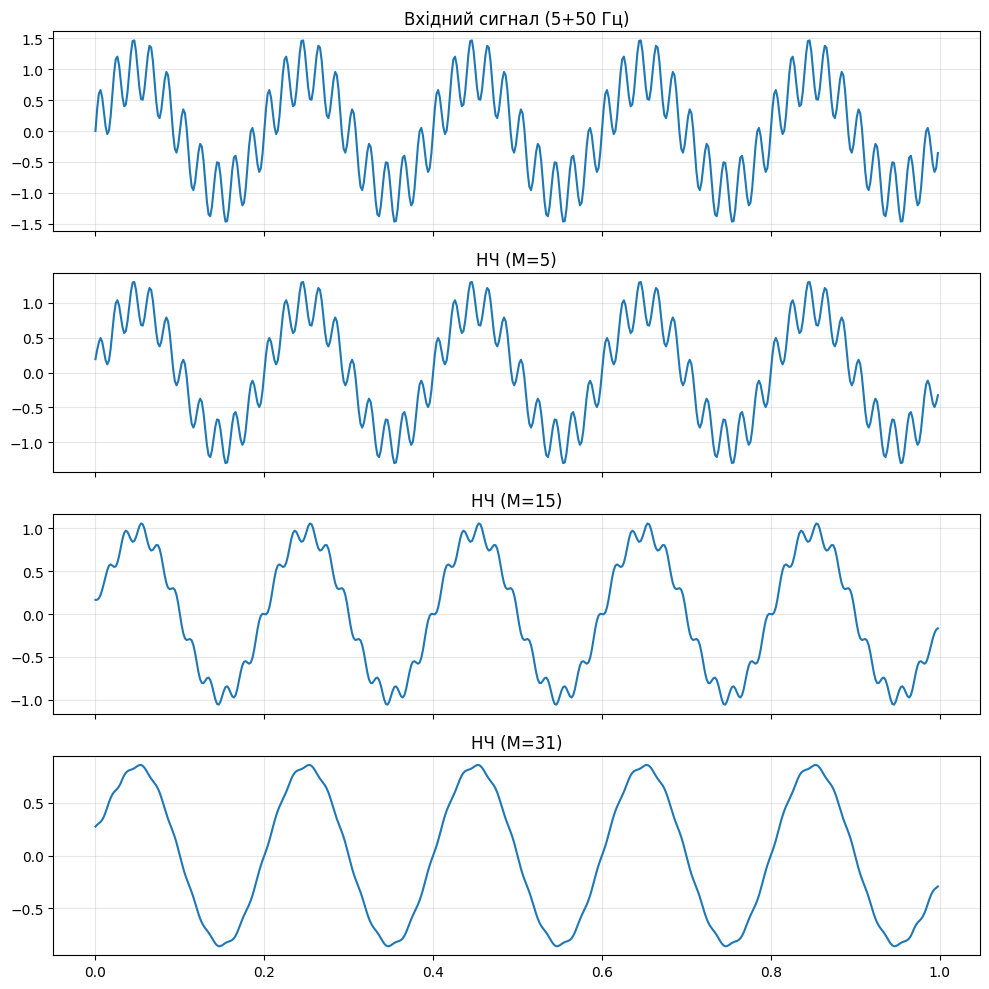

In [3]:
# 1.	Змінити довжину ядра НЧ-фільтра та порівняти результати для M = 5, 15, 31.
fs = 500
t, x_orig = generate_signal(fs=fs, freqs=[5, 50])

results = []
x_data = calculate_metrics(x_orig)
results.append({"Фільтр": "Без фільтрів", **x_data, "Опис": "Оригінальний сигнал"})

signals = [x_orig]
titles = [f"Вхідний сигнал (5+50 Гц)"]
for m in [5, 15, 31]:
    y = apply_low_pass_fir(x_orig, m)
    m_data = calculate_metrics(y)
    results.append({"Фільтр": f"НЧ (M={m})", **m_data, "Опис": "Згладжування"})
    signals.append(y)
    titles.append(f"НЧ (M={m})")

plot_comparison(t, signals, titles)


In [4]:
# --- Створення таблиці ---
df = pd.DataFrame(results).round(4)
print("Аналіз характеристик сигналу після фільтрації:")
display(df)

Аналіз характеристик сигналу після фільтрації:


,Фільтр,Mean,Energy,RMS,Опис
0,Без фільтрів,0.0000,312.5000,0.7906,Оригінальний сигнал
1,НЧ (M=5),0.0004,274.3315,0.7407,Згладжування
2,НЧ (M=15),0.0003,235.4799,0.6863,Згладжування
3,НЧ (M=31),0.0005,182.4302,0.6040,Згладжування


**Спостереження:**

Вплив довжини ядра: чим більше М, тим сильніше фільтр придушує високі частоти.

Зміна енергетичних характеристик: зі збільшенням М зменшуються значення Energy та RMS. Це свідчить про ефективне відфільтровування високочастотної складової сигналу, яка робила внесок у загальну потужність.

Якість фільтрації: мале значення (М = 5) дозволяє зберегти форму сигналу, але погано справляється з  високими частотами; велике значення (М = 31) забезпечує відмінне згладжування та може привести до втрати корисного сигналу, якщо він має високу частоту


##2.Додати до сигналу випадковий шум різної інтенсивності та оцінити якість фільтрації.

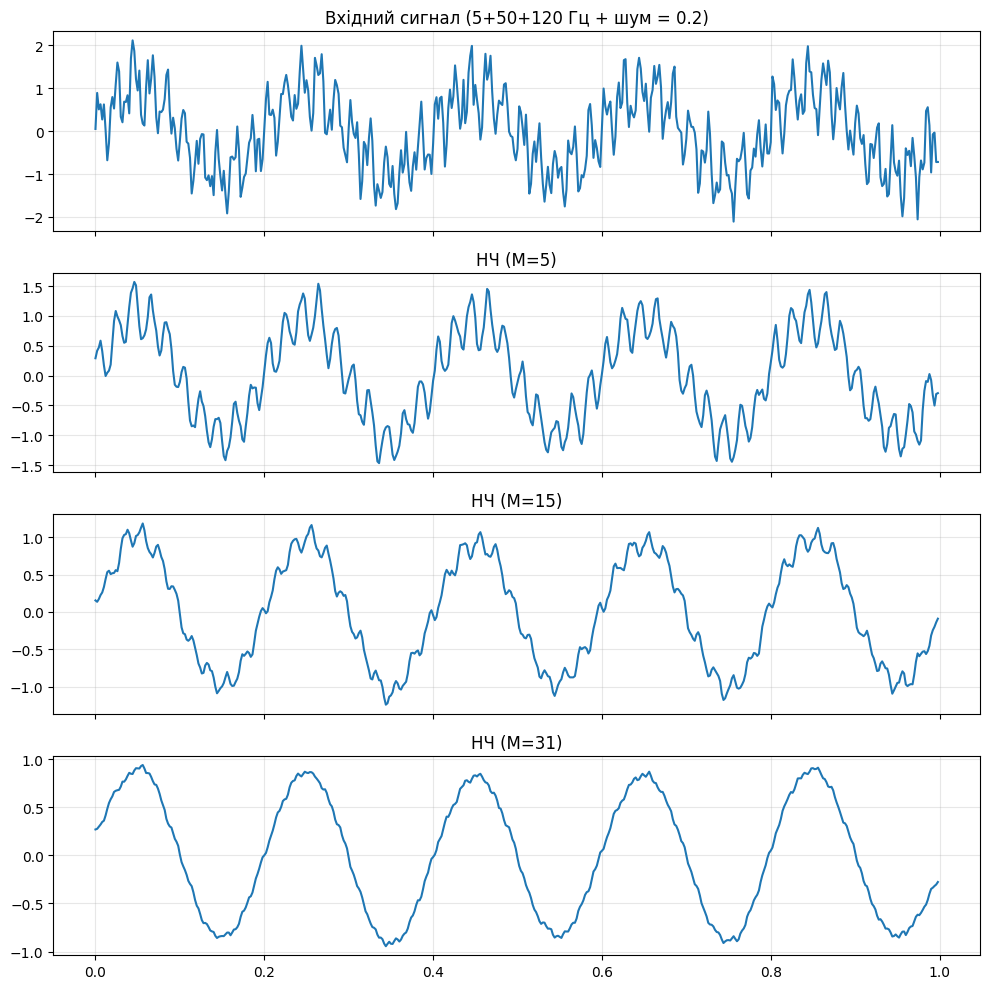

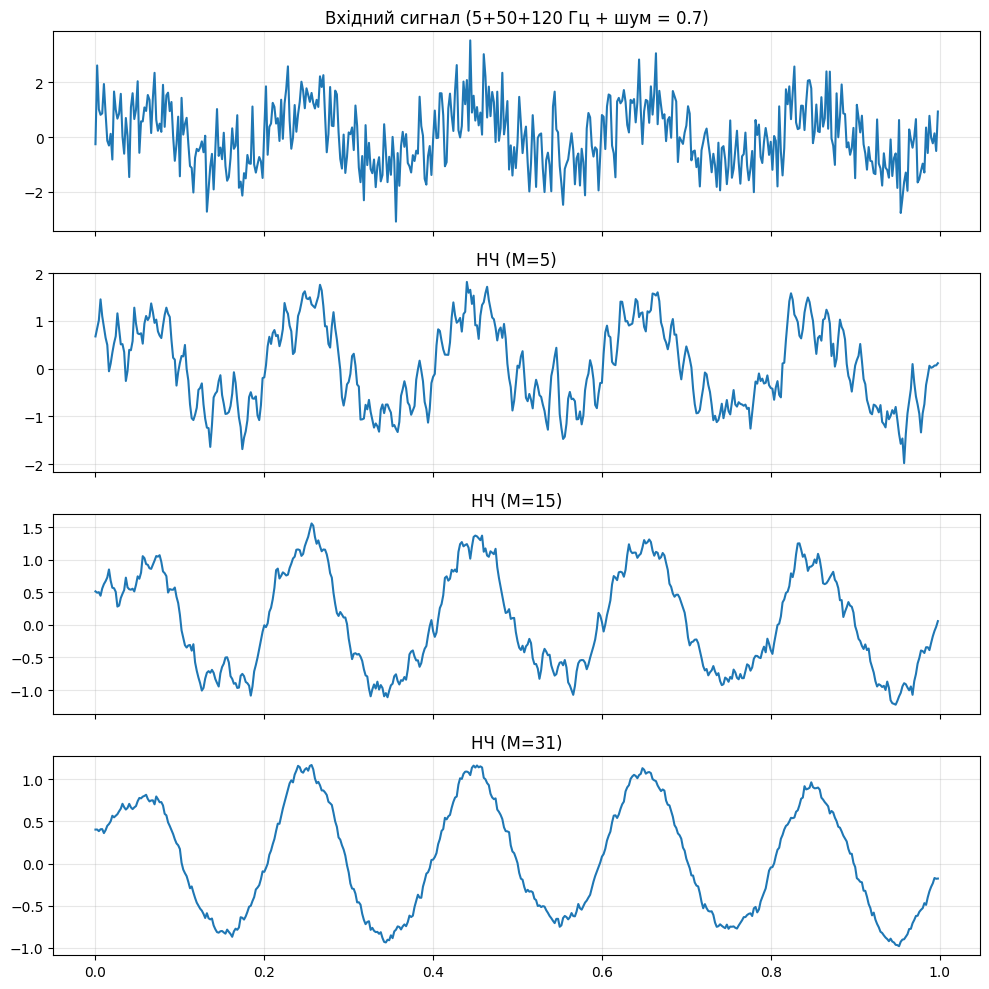

In [5]:
# 2.	Додати до сигналу випадковий шум різної інтенсивності та оцінити якість фільтрації.
results = []
for noise in [0.2, 0.7]:
  t, x_orig = generate_signal(fs=fs, freqs=[5, 50, 120], amps=[1.0, 0.6, 0.4], noise_std=noise)
  x_data = calculate_metrics(x_orig)
  results.append({"Фільтр": "Без фільтрів", **x_data, "Опис": f"Оригінальний сигнал, noise = {noise}"})

  signals = [x_orig]
  titles = [f"Вхідний сигнал (5+50+120 Гц + шум = {noise})"]
  for m in [5, 15, 31]:
    y = apply_low_pass_fir(x_orig, m)
    m_data = calculate_metrics(y)
    results.append({"Фільтр": f"НЧ (M={m})", **m_data, "Опис": "Згладжування шуму"})
    signals.append(y)
    titles.append(f"НЧ (M={m})")
  plot_comparison(t, signals, titles)


In [6]:
# --- Створення таблиці ---
df = pd.DataFrame(results).round(4)
print("Аналіз характеристик сигналу після фільтрації:")
display(df)

Аналіз характеристик сигналу після фільтрації:


,Фільтр,Mean,Energy,RMS,Опис
0,Без фільтрів,0.0008,401.6969,0.8963,"Оригінальний сигнал, noise = 0.2"
1,НЧ (M=5),0.0013,298.0984,0.7721,Згладжування шуму
2,НЧ (M=15),0.0007,246.2493,0.7018,Згладжування шуму
3,НЧ (M=31),0.0010,189.4568,0.6156,Згладжування шуму
4,Без фільтрів,0.0555,664.0101,1.1524,"Оригінальний сигнал, noise = 0.7"
5,НЧ (M=5),0.0541,370.9596,0.8613,Згладжування шуму
6,НЧ (M=15),0.0510,289.6689,0.7611,Згладжування шуму
7,НЧ (M=31),0.0505,216.4954,0.6580,Згладжування шуму


**Спостереження:**

Залежність енергії від шуму: випадковий шум суттєво підвищує Energy та RMS. Це заважає вимірюванню параметрів корисного сигналу, тому попередня фільтрація є обов’язковою.

Ефективність фільтра ковзного середнього: працює як низькочастотний фільтр, найкраще підходить для придушення «білого шуму», оскільки випадкові відхилення (додатні та від’ємні) взаємознищуються під час підсумовування всередині вікна фільтра.

Якість фільтрації: мале значення (М = 5) дозволяє зберегти форму сигналу, зберігаються високі частоти та частково шум; велике значення (М = 31) забезпечує достатньо «чисту» хвилю, але повністю втрачається інформація про швидкі коливання.


##3.Побудувати сигнал із трьох гармонік і виділити одну з них смуговим фільтром.

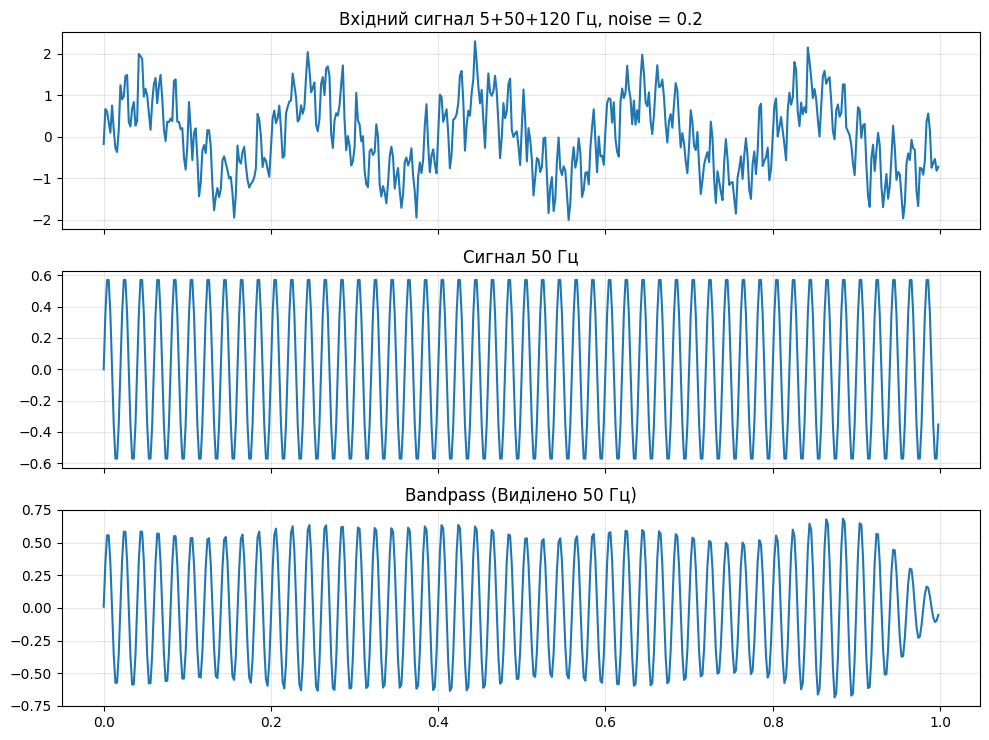

In [7]:
# 3.	Побудувати сигнал із трьох гармонік і виділити одну з них смуговим фільтром.
t, x_orig = generate_signal(fs=fs, freqs=[5, 50, 120], amps=[1.0, 0.6, 0.4], noise_std=0.2)

results = []
x_data = calculate_metrics(x_orig)
results.append({"Фільтр": "Без фільтрів", **x_data, "Опис": f"Вхідний сигнал 5+50+120 Гц, noise = 0.2"})


t, sig_50 = generate_signal(fs=fs, freqs=[50], amps=[0.6])
sig_50_data = calculate_metrics(sig_50)
results.append({"Фільтр": "Без фільтрів", **sig_50_data, "Опис": f"Сигнал 50 Гц"})

y_pass = apply_band_filter(x_orig, fs, 45, 55, btype='bandpass')
y_pass_data = calculate_metrics(y_pass)
results.append({"Фільтр": "Bandpass", **y_pass_data, "Опис": f"Виділено 50 Гц"})

plot_comparison(t,
                [x_orig, sig_50, y_pass],
                ["Вхідний сигнал 5+50+120 Гц, noise = 0.2", "Сигнал 50 Гц", "Bandpass (Виділено 50 Гц)"])


In [8]:
# --- Створення таблиці ---
df = pd.DataFrame(results).round(4)
print("Аналіз характеристик сигналу після фільтрації:")
display(df)

Аналіз характеристик сигналу після фільтрації:


,Фільтр,Mean,Energy,RMS,Опис
0,Без фільтрів,0.0124,408.8579,0.9043,"Вхідний сигнал 5+50+120 Гц, noise = 0.2"
1,Без фільтрів,0.0000,90.0000,0.4243,Сигнал 50 Гц
2,Bandpass,0.0015,87.4609,0.4182,Виділено 50 Гц


**Спостереження:**

Точність: Порівняння RMS відфільтрованого сигналу з RMS чистої гармоніки підтвердило високу точність обраного методу цифрової фільтрації (фільтр Баттерворта 4-го порядку).

Смуговий фільтр успішно виділив цільову гармоніку 50 Гц із зашумленого сигналу, що містив компоненти як нижчої 5 Гц так і вищої 120 Гц частот. Незважаючи на наявність випадкового шуму, на виході фільтра отримано чисту синусоїдальну форму, що підтверджується близькістю енергетичних характеристик до ідеального сигналу.

Даний експеримент демонструє принцип роботи селективних вузлів у сучасній електроніці: здатність виділити корисний сигнал заданої частоти, ігноруючи потужні завади в інших частотних діапазонах.


##4.Реалізувати смугозагороджувальний фільтр і дослідити його роботу.

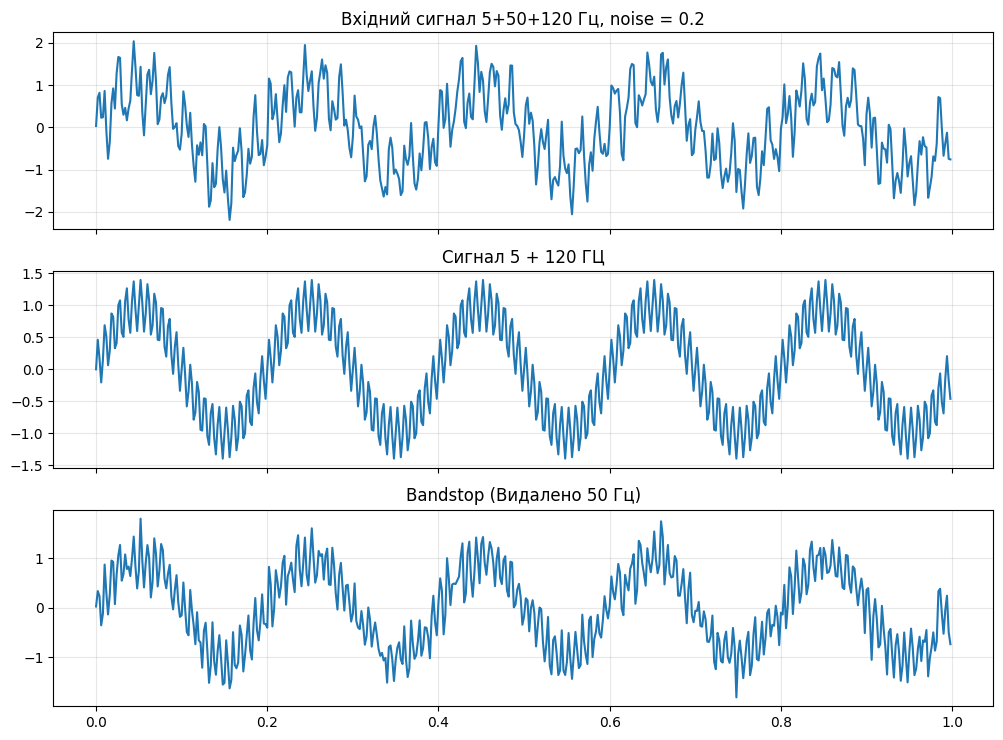

In [9]:
# 4.	Реалізувати смугозагороджувальний фільтр і дослідити його роботу.
t, x_orig = generate_signal(fs=fs, freqs=[5, 50, 120], amps=[1.0, 0.6, 0.4], noise_std=0.2)

results = []
x_data = calculate_metrics(x_orig)
results.append({"Фільтр": "Без фільтрів", **x_data, "Опис": f"Вхідний сигнал 5+50+120 Гц, noise = 0.2"})

# Ідеальний сигнал, який ми хочемо отримати (тільки 5 Гц та 120 Гц)
t, sig_ideal = generate_signal(fs=fs, freqs=[5, 120], amps=[1.0, 0.4])
sig_ideal_data = calculate_metrics(sig_ideal)
results.append({"Фільтр": "Еталон (5+120)", **sig_ideal_data, "Опис": "Ідеальний сигнал без шуму"})


y_stop = apply_band_filter(x_orig, fs, 45, 55, btype='bandstop')
y_stop_data = calculate_metrics(y_stop)
results.append({"Фільтр": "Bandstop", **y_stop_data, "Опис": f"Видалено 50 Гц"})

plot_comparison(t,
                [x_orig, sig_ideal, y_stop],
                ["Вхідний сигнал 5+50+120 Гц, noise = 0.2", "Сигнал 5 + 120 ГЦ", "Bandstop (Видалено 50 Гц)"])


In [10]:
# --- Створення таблиці ---
df = pd.DataFrame(results).round(4)
print("Аналіз характеристик сигналу після фільтрації:")
display(df)

Аналіз характеристик сигналу після фільтрації:


,Фільтр,Mean,Energy,RMS,Опис
0,Без фільтрів,-0.0029,398.3926,0.8926,"Вхідний сигнал 5+50+120 Гц, noise = 0.2"
1,Еталон (5+120),0.0000,290.0000,0.7616,Ідеальний сигнал без шуму
2,Bandstop,-0.0037,313.4165,0.7917,Видалено 50 Гц


**Спостереження:**

Точність: смугозагороджувальний фільтр (Bandstop) успішно видалив цільову гармоніку 50 Гц. Порівняння результату RMS з ідеальним еталоном показало, що фільтр зберіг основну енергію інших корисних складових сигналу.

Експеримент продемонстрував, що фільтр Bandstop видаляє шум лише у смузі своєї дії. На відміну від НЧ-фільтра, він пропускає високочастотний шум (вище 55 Гц), що пояснює дещо вищий  RMS відфільтрованого сигналу порівняно з ідеальним.

Візуальний аналіз графіків підтверджує, що форма сигналу залишилася впізнаваною, а амплітуда повільної хвилі (5 Гц) не зазнала видимих втрат.

Смугозагороджувальні фільтри є незмінними в ситуаціях, коли корисна інформація знаходиться як у низькочастотній так і високочастотній областях, а завада має вузький спектр.


##5.Порівняти результати згортки у режимах same та full.

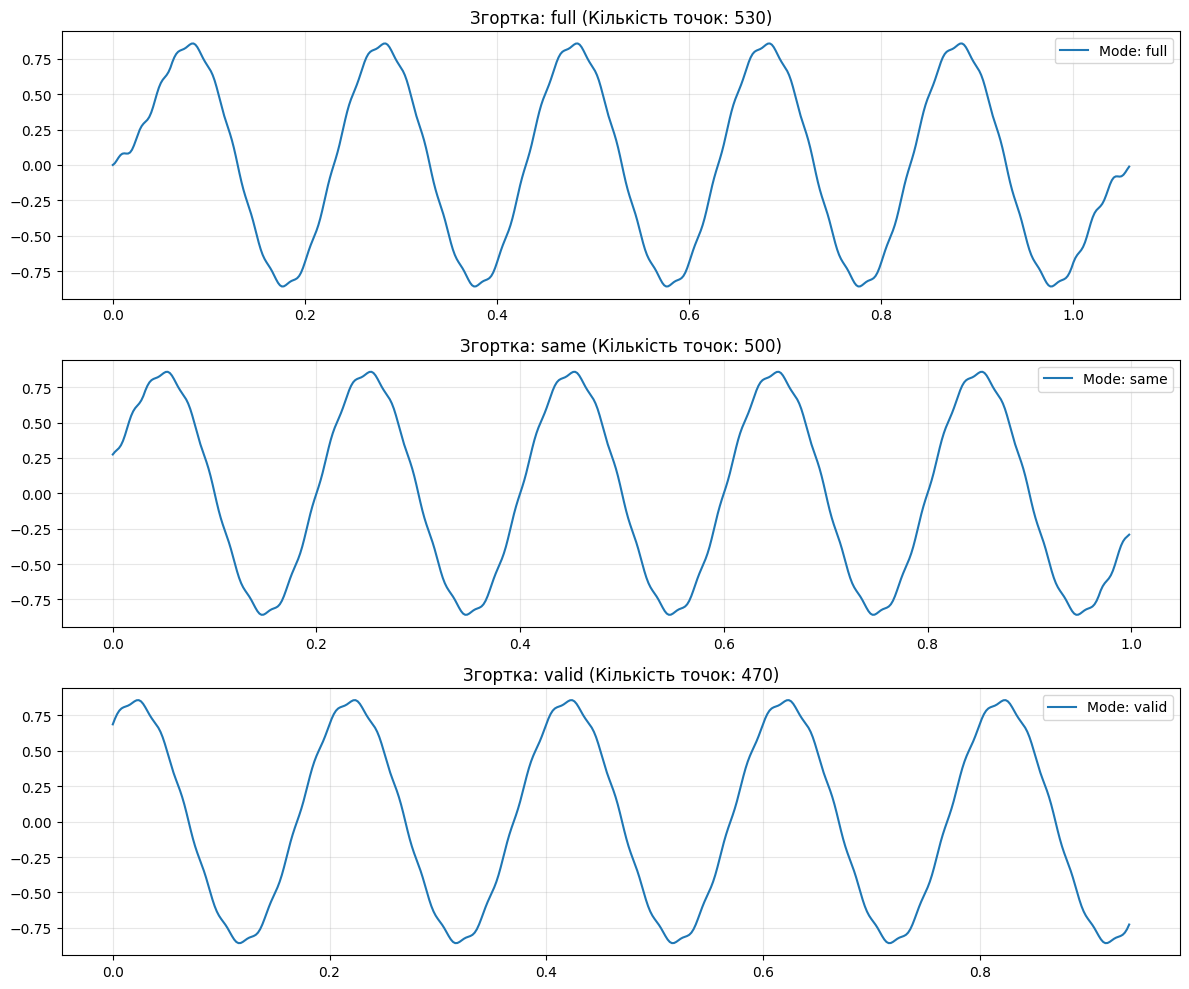

In [11]:
# 5.	Порівняти результати згортки у режимах same та full.

def calculate_metrics_fixed(sig_input):
    s = np.array(sig_input)
    m_val = np.mean(s)
    eng = np.sum(s**2)
    pwr = np.mean(s**2)
    rms = np.sqrt(pwr)
    return m_val, eng, pwr, rms

# Параметри
fs = 500
t_orig = np.arange(0, 1, 1/fs)
# Сигнал 5 Гц + 50 Гц
x_orig = np.sin(2 * np.pi * 5 * t_orig) + 0.5 * np.sin(2 * np.pi * 50 * t_orig)

M = 31
kernel = np.ones(M) / M
modes = ['full', 'same', 'valid']
results_list = []

plt.figure(figsize=(12, 10))

for i, m in enumerate(modes):
    # Виконуємо згортку
    y = np.convolve(x_orig, kernel, mode=m)

    # Розраховуємо метрики
    m_val, eng, pwr, rms = calculate_metrics_fixed(y)

    # Зберігаємо результати
    results_list.append({
        "Режим (mode)": m,
        "Довжина (N)": len(y),
        "Mean": round(m_val, 6),
        "Energy": round(eng, 4),
        "RMS": round(rms, 6)
    })

    # Графік
    plt.subplot(3, 1, i+1)
    t_axis = np.arange(0, len(y)) / fs
    plt.plot(t_axis, y, label=f"Mode: {m}")
    plt.title(f"Згортка: {m} (Кількість точок: {len(y)})")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Вивід таблиці
df_res = pd.DataFrame(results_list).round(3)
print("\nПорівняльна таблиця режимів згортки:")
print(df_res.to_string(index=False))


Порівняльна таблиця режимів згортки:
Режим (mode)  Довжина (N)  Mean  Energy   RMS
        full          530 0.000 182.927 0.587
        same          500 0.001 182.430 0.604
       valid          470 0.001 175.127 0.610


**Спостереження:**

Експеримент продемонстрував наявність «перехідних процесів» на початку та в кінці згортки. У режимах full та same ці ефекти призводить до зниження RMS.

- mode = same  - зручний для візуалізації та задач, де важливо зберігати часову відповідність між входом і виходом (однакова довжина масивів).

- mode = valid – найкращий для точних метрологічних розрахунків (Mean, RMS), оскільки він виключає спотворені ділянки «наростання» та «згасання» сигналу на краях.

- mode = full – дозволяє побачити повну тривалість відгуку системи на вплив, що важливо при дослідженні імпульсних характеристик.

Різниця в сумарній енергії між режимами зумовлена кількістю відліків, що потрапляють у розрахунок, тоді як фізичний зміст сигналу залишається ідентичним у центральній частині кожного масиву.


##6.Використати власний вхідний сигнал з аудіофайлу або файлу експериментальних вимірювань.

In [13]:
# 6.	Використати власний вхідний сигнал з аудіофайлу або файлу експериментальних вимірювань.
from scipy import datasets

# Завантаження сигналу ЕКГ
ecg = datasets.electrocardiogram()
fs = 360  # Частота дискретизації для цього сигналу
t = np.arange(len(ecg)) / fs

# перші 5 секунд
sig = ecg[:fs*5]
t_sig = t[:fs*5]

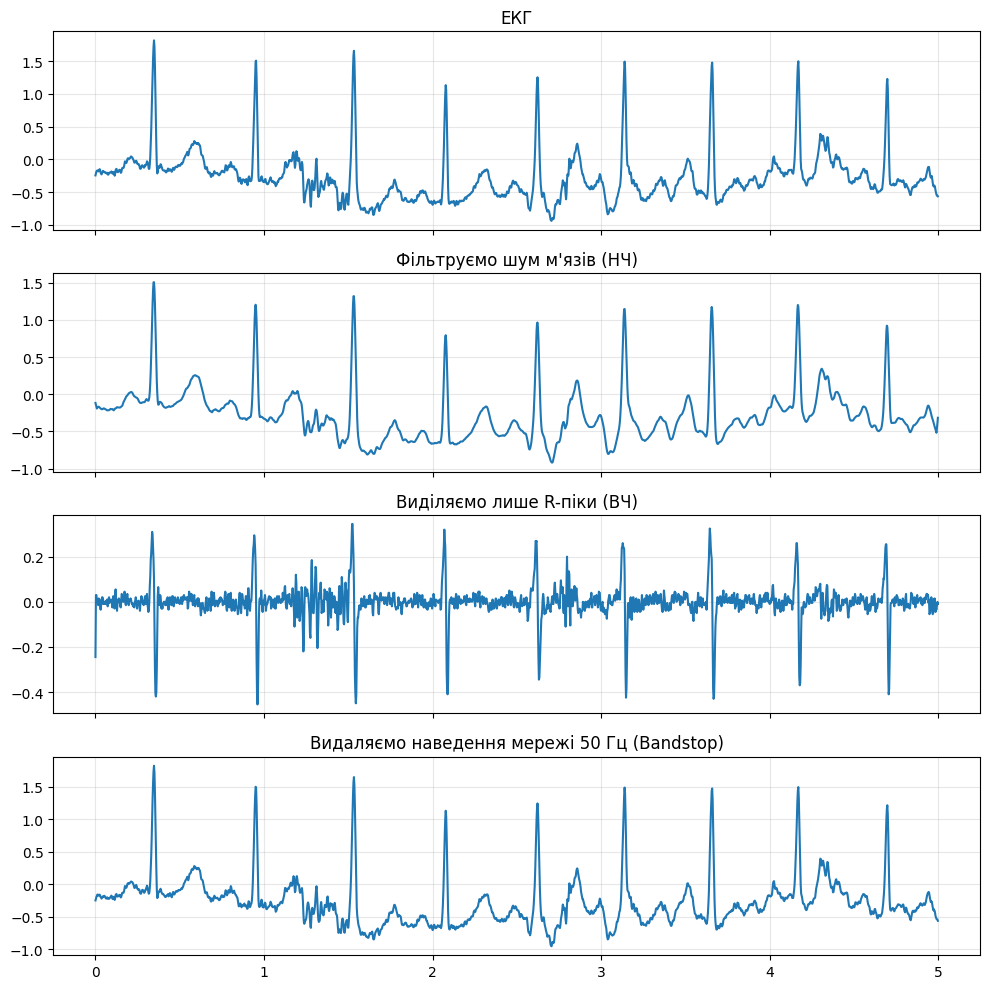

In [14]:
results = []
x_data = calculate_metrics(sig)
results.append({"Фільтр": "Без фільтрів", **x_data, "Опис": "Оригінальний сигнал"})


# 1. Фільтруємо шум м'язів (НЧ)
clean_low = apply_low_pass_fir(sig, M=7)
clean_low_data = calculate_metrics(clean_low)
results.append({"Фільтр": "НЧ", **clean_low_data, "Опис": "Фільтруємо шум м'язів"})

# 2. Виділяємо лише R-піки (ВЧ)
peaks_only = apply_high_pass_diff(sig)
peaks_only_data = calculate_metrics(peaks_only)
results.append({"Фільтр": "ВЧ", **peaks_only_data, "Опис": " Виділяємо лише R-піки"})

# 3. Видаляємо наведення мережі 50 Гц (Bandstop)
no_hum = apply_band_filter(sig, fs=360, low=48, high=52, btype='bandstop')
no_hum_data = calculate_metrics(no_hum)
results.append({"Фільтр": "Смугозагороджувальний", **no_hum_data, "Опис": " Видаляємо наведення мережі 50 Гц"})

plot_comparison(t_sig,
                [sig, clean_low, peaks_only, no_hum],
                ["ЕКГ","Фільтруємо шум м'язів (НЧ)", "Виділяємо лише R-піки (ВЧ)", "Видаляємо наведення мережі 50 Гц (Bandstop)"])


##7.Оцінити зміну середнього значення, енергії або RMS сигналу після фільтрації.

In [15]:
# 7.	Оцінити зміну середнього значення, енергії або RMS сигналу після фільтрації.
df = pd.DataFrame(results).round(4)
print("Аналіз характеристик сигналу після фільтрації:")
display(df)

Аналіз характеристик сигналу після фільтрації:


,Фільтр,Mean,Energy,RMS,Опис
0,Без фільтрів,-0.2769,390.2074,0.4656,Оригінальний сигнал
1,НЧ,-0.2765,357.0932,0.4454,Фільтруємо шум м'язів
2,ВЧ,-0.0003,10.8960,0.0778,Виділяємо лише R-піки
3,Смугозагороджувальний,-0.2769,389.8767,0.4654,Видаляємо наведення мережі 50 Гц


**Спостереження:**

Реальний сигнал ЕКГ має складний спектр і ненульове середнє значення, що потребує комбінованого підходу до фільтрації.

Використання НЧ-фільтра з невеликим вікном (М = 7) дозволило усунути високочастотні завади без суттєвого спотворення форми корисних зубців ЕКГ.

Різницевий оператор виявився ефективним для виділення R-піків. Повне видалення низькочастотної енергії дозволяє перетворити складний сигнал на послідовність імпульсів, зручних для вимірювання серцевого ритму.

Порівняння енергії після різних типів фільтраціє показало, що основна корисна інформація ЕКГ зосереджена в низькочастотній та середньочастотній областях, тоді як високочастотні складники мають значно меншу амплітуду.


##8.Реалізувати FIR-фільтр із симетричними коефіцієнтами та пояснити його властивості.

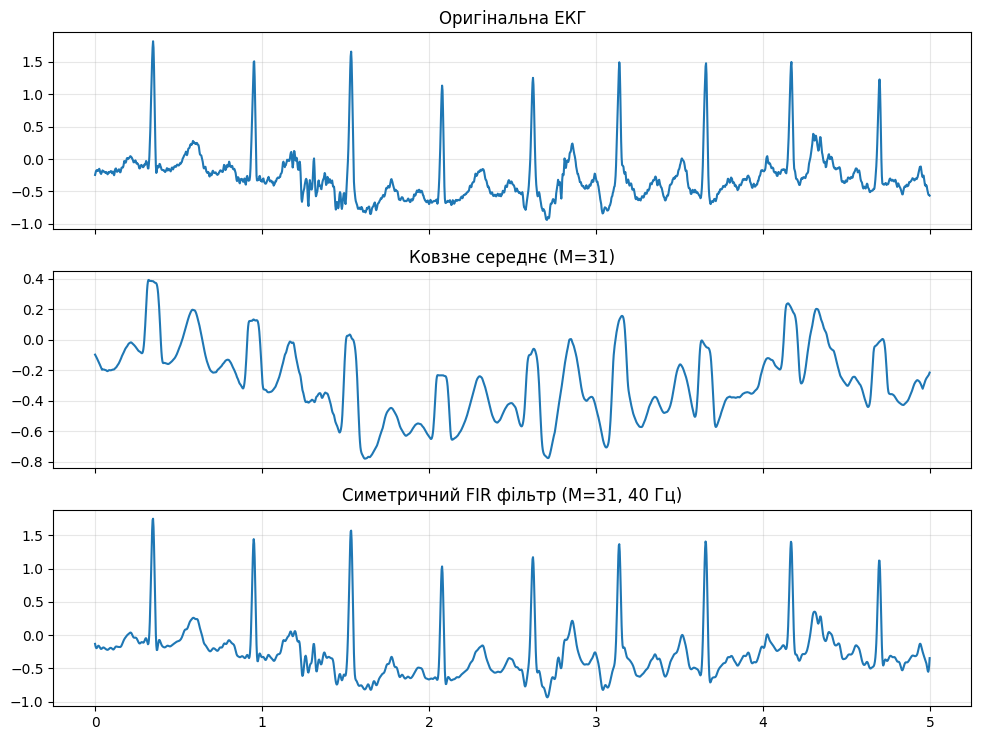

In [16]:
# 8.	Реалізувати FIR-фільтр із симетричними коефіцієнтами та пояснити його властивості.

from scipy.signal import firwin

def apply_symmetric_fir(sig, fs, cutoff, numtaps=31):
    """
    FIR-фільтр із симетричними коефіцієнтами (вікно Хеммінга).
    """
    # Генеруємо ядро (коефіцієнти)
    kernel = firwin(numtaps, cutoff, fs=fs, window='hamming')

    # Виконуємо згортку
    return np.convolve(sig, kernel, mode='same'), kernel

# той самий сигнал ЕКГ
fs_ecg = 360
ecg_full = datasets.electrocardiogram()
sig_ecg = ecg_full[:fs_ecg*5]  # перші 5 секунд
t_ecg = np.arange(len(sig_ecg)) / fs_ecg

results = []

# Метрики оригіналу
results.append({"Фільтр": "Оригінал ЕКГ", **calculate_metrics(sig_ecg), "Опис": "Без обробки"})

# Простий НЧ (Ковзне середнє) M=31
y_ma = apply_low_pass_fir(sig_ecg, M=31)
results.append({"Фільтр": "НЧ (Ковзне середнє) M=31", **calculate_metrics(y_ma), "Опис": "Просте усереднення"})

# Симетричний FIR (firwin) M=31
y_fir, kernel_fir = apply_symmetric_fir(sig_ecg, fs=fs_ecg, cutoff=40, numtaps=31)
results.append({"Фільтр": "Симетричний FIR M=31", **calculate_metrics(y_fir), "Опис": "Windowed Sinc (Hamming)"})


# Графік порівняння сигналів
plot_comparison(t_ecg,
                [sig_ecg, y_ma, y_fir],
                ["Оригінальна ЕКГ", "Ковзне середнє (M=31)", "Симетричний FIR фільтр (M=31, 40 Гц)"])


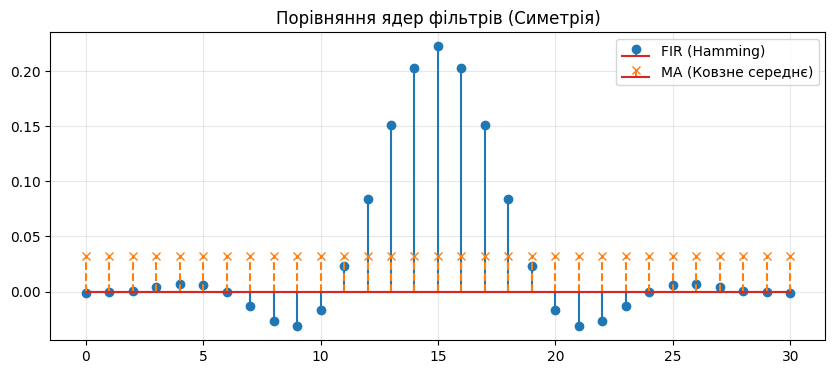

In [17]:
# Графік ядер (коефіцієнтів) - щоб побачити симетрію
plt.figure(figsize=(10, 4))
plt.stem(kernel_fir, linefmt='C0-', markerfmt='C0o', label='FIR (Hamming)')

# Для порівняння додамо ядро ковзного середнього
plt.stem(np.ones(31)/31, linefmt='C1--', markerfmt='C1x', label='MA (Ковзне середнє)')
plt.title("Порівняння ядер фільтрів (Симетрія)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [18]:
# --- ТАБЛИЦЯ РЕЗУЛЬТАТІВ ---
df_fir = pd.DataFrame(results).round(5)
print("Порівняння простого усереднення та проектованого FIR-фільтра:")
display(df_fir)

Порівняння простого усереднення та проектованого FIR-фільтра:


,Фільтр,Mean,Energy,RMS,Опис
0,Оригінал ЕКГ,-0.27686,390.20740,0.46560,Без обробки
1,НЧ (Ковзне середнє) M=31,-0.27541,241.54937,0.36633,Просте усереднення
2,Симетричний FIR M=31,-0.27665,386.20443,0.46320,Windowed Sinc (Hamming)


**Спостереження:**

Побудоване ядро FIR-фільтра є строго симетричним відносно свого центру. Це забезпечує лінійну фазову характеристику, що є критичним для медичних сигналів, оскільки такий фільтр не зміщує різні частоти одну відносно одної в часі (зберігає форму зубців ЕКГ).

Хоча обидва фільтри мають однакову довжину (М = 31), FIR-фільтр на основі вікна Хемінга забезпечує кращу якість: він зберігає бальше енергії корисного сигналу (вищий RMS у таблиці) при аналогічному рівні придушення високих частот.

Порівняння енергій показало, що проектований FIR-фільтр є більш селективним. Він має крутіший зріз частотної характеристики, що мінімізує втрати амплітуди корисних складових.

Оскільки FIR-фільтр реалізований через пряму згортку без зворотного зв’язку, він є стабільним і забезпечує прогнозований результат на будь-яких ділянках експериментального сигналу.
